# NAMA     : SRI ZUL'AINI ULYA
# NIM      : F1D02410096
# KELOMPOK : 10

In [19]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

Kode tersebut mengimpor tiga pustaka (library) utama yang sangat krusial dan menjadi standar dalam pemrograman pemrosesan citra digital dengan Python. NumPy (import numpy as np) digunakan untuk komputasi numerik tingkat lanjut dan mengelola data gambar yang pada dasarnya dibaca oleh komputer sebagai matriks atau array angka multi-dimensi. OpenCV (import cv2 as cv) adalah pustaka khusus computer vision yang menyediakan ratusan alat untuk membaca, memanipulasi, dan memproses gambar itu sendiri. Sementara itu, Matplotlib (import matplotlib.pyplot as plt) adalah pustaka visualisasi yang bertugas untuk menampilkan hasil akhir ke layar

In [20]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('on')

Kode tersebut mendefinisikan sebuah fungsi kustom bernama show yang dibuat untuk menyederhanakan proses menampilkan gambar ke layar agar kamu tidak perlu menulis ulang banyak baris perintah berkali-kali. Fungsi ini menerima data gambar (img) dan judul opsional (title), lalu menggunakan plt.imshow dengan pengaturan cmap='gray' untuk memaksa gambar tersebut ditampilkan dalam format warna abu-abu (grayscale), yang sangat umum digunakan dalam analisis citra. Selain menyematkan teks judul di atas gambar melalui plt.title, fungsi ini juga menyertakan plt.axis('on') untuk memastikan angka skala koordinat piksel pada bingkai sumbu X dan Y tetap terlihat.

In [21]:
def rgb2gray(rgb):
    if rgb.shape[-1] == 4:
        rgb = rgb[..., :3]
    return np.dot(rgb, [0.2989, 0.5870, 0.1140])

Fungsi rgb2gray ini bertugas untuk mengonversi matriks gambar berwarna menjadi format grayscale (skala abu-abu) secara manual menggunakan perhitungan matematis standar. Pada baris awalnya, fungsi ini mengecek apakah gambar memiliki format RGBA (terdiri dari 4 channel karena memiliki elemen transparansi atau alpha); jika ya, channel transparansi tersebut akan dibuang sehingga murni menyisakan data warna dasar Red, Green, dan Blue (RGB).

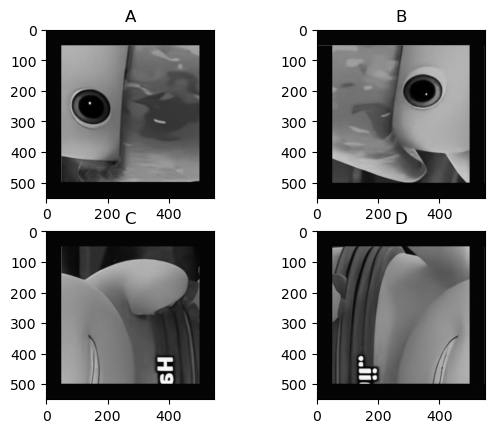

In [22]:
img1 = plt.imread("assets/Dino-A.png")
img2 = plt.imread("assets/Dino-B.png")
img3 = plt.imread("assets/Dino-C.png")
img4 = plt.imread("assets/Dino-D.png")

gray1 = rgb2gray(img1)
gray2 = rgb2gray(img2)
gray3 = rgb2gray(img3)
gray4 = rgb2gray(img4)

plt.subplot(2, 2, 1)
plt.imshow(gray1, cmap='gray')
plt.title('A')

plt.subplot(2, 2, 2)
plt.imshow(gray2, cmap='gray')
plt.title('B')

plt.subplot(2, 2, 3)
plt.imshow(gray3, cmap='gray')
plt.title('C')

plt.subplot(2, 2, 4)
plt.imshow(gray4, cmap='gray')
plt.title('D')

plt.show()

Kode ini berfungsi untuk membaca empat gambar, mengonversinya menjadi format hitam putih (grayscale), dan menampilkannya secara bersamaan ke layar dalam susunan tata letak grid berukuran 2x2.

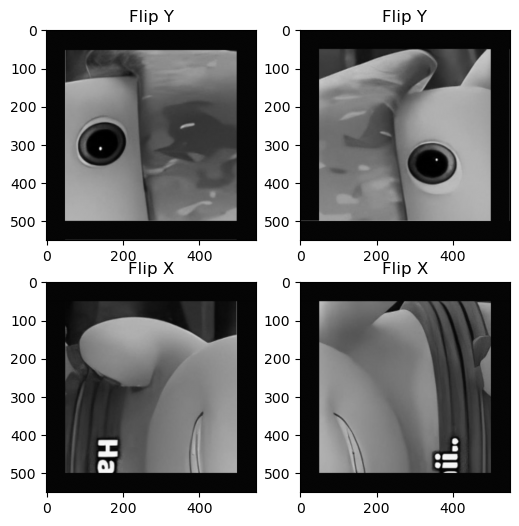

In [23]:
def flip(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[i, w-1-j]
            elif mode == 'Y':
                hasil[i, j] = image[h-1-i, j]
    return hasil

plt.figure(figsize=(6, 6))

flip_1 = flip(gray1, 'Y')
flip_2 = flip(gray2, 'Y')
flip_3 = flip(gray3, 'X')
flip_4 = flip(gray4, 'X') 

plt.subplot(2, 2, 1)
show(flip_1, "Flip Y")

plt.subplot(2, 2, 2)
show(flip_2, "Flip Y")

plt.subplot(2, 2, 3)
show(flip_3, "Flip X")  

plt.subplot(2, 2, 4)
show(flip_4, "Flip X")

Kode ini mendefinisikan fungsi manual untuk membalikkan posisi piksel gambar secara horizontal (sumbu X) maupun vertikal (sumbu Y), lalu menerapkannya dengan membalik gambar pertama dan kedua secara vertikal serta gambar ketiga dan keempat secara horizontal, untuk kemudian ditampilkan bersamaan dalam format grid 2x2.

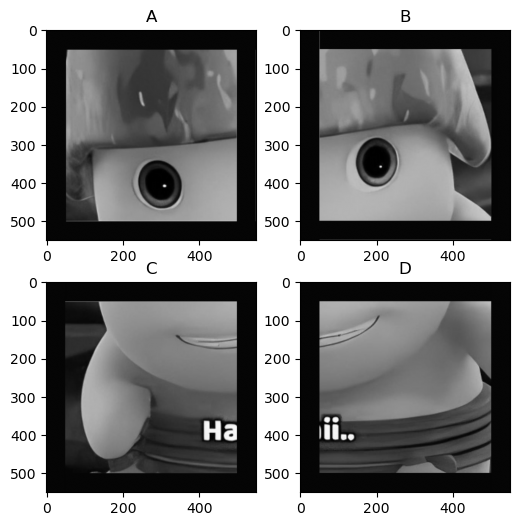

In [24]:
def rotate_manual(img, angle):
    rad = np.deg2rad(angle)
    h, w = img.shape[0], img.shape[1]

    new_w = int(abs(w * np.cos(rad)) + abs(h * np.sin(rad)))
    new_h = int(abs(h * np.cos(rad)) + abs(w * np.sin(rad)))

    cx_old, cy_old = w // 2, h // 2
    cx_new, cy_new = new_w // 2, new_h // 2

    hasil = np.zeros((new_h, new_w), dtype=img.dtype)

    for y in range(new_h):
        for x in range(new_w):
            x_rel = x - cx_new
            y_rel = y - cy_new

            x_old = int(x_rel * np.cos(rad) + y_rel * np.sin(rad) + cx_old)
            y_old = int(-x_rel * np.sin(rad) + y_rel * np.cos(rad) + cy_old)

            if 0 <= x_old < w and 0 <= y_old < h:
                hasil[y, x] = img[y_old, x_old]

    return hasil

plt.figure(figsize=(6, 6))
rotasi1 = rotate_manual(flip_1, -90)
rotasi2 = rotate_manual(flip_2, 90)
rotasi3 = rotate_manual(flip_3, -90)
rotasi4 = rotate_manual(flip_4, 90)

plt.subplot(2, 2, 1)
show(rotasi1, "A")

plt.subplot(2, 2, 2)
show(rotasi2, "B")

plt.subplot(2, 2, 3)
show(rotasi3, "C")  

plt.subplot(2, 2, 4)
show(rotasi4, "D")


Kode ini membuat fungsi rotasi gambar secara manual menggunakan perhitungan trigonometri, lalu menerapkannya untuk memutar keempat gambar yang sudah dibalik sebelumnya sebesar 90 atau -90 derajat, dan menampilkannya kembali secara bersamaan dalam susunan grid 2x2.

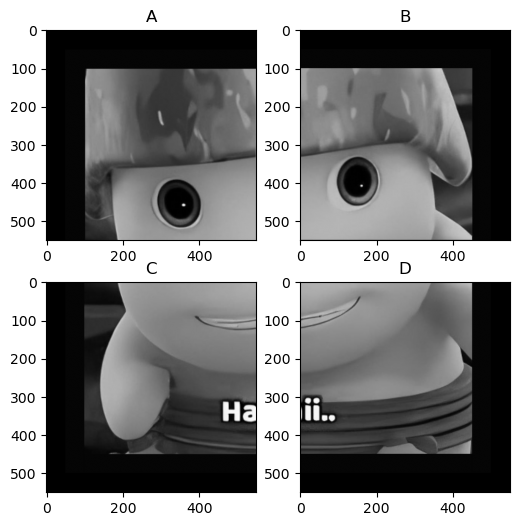

In [25]:
def translasi(image, geser_kolom_x=0, geser_baris_y=0):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            new_i = i + geser_baris_y
            new_j = j + geser_kolom_x
            if 0 <= new_i < h and 0 <= new_j < w:
                hasil[new_i, new_j] = image[i, j]
    return hasil

plt.figure(figsize=(6, 6))

geser1 = translasi(rotasi1, geser_kolom_x=50, geser_baris_y=50)
geser2 = translasi(rotasi2, geser_kolom_x=-50, geser_baris_y=50)
geser3 = translasi(rotasi3, geser_kolom_x=50, geser_baris_y=-50)
geser4 = translasi(rotasi4, geser_kolom_x=-50, geser_baris_y=-50)

plt.subplot(2, 2, 1)
show(geser1, "A")

plt.subplot(2, 2, 2)
show(geser2, "B")

plt.subplot(2, 2, 3)
show(geser3, "C")

plt.subplot(2, 2, 4)
show(geser4, "D")

Kode ini mendefinisikan fungsi translasi untuk menggeser posisi piksel gambar secara horizontal dan vertikal, lalu menerapkannya pada keempat gambar sebelumnya dengan arah pergeseran yang berbeda-beda sejauh 50 piksel, dan menampilkannya kembali ke layar dalam susunan grid 2x2.

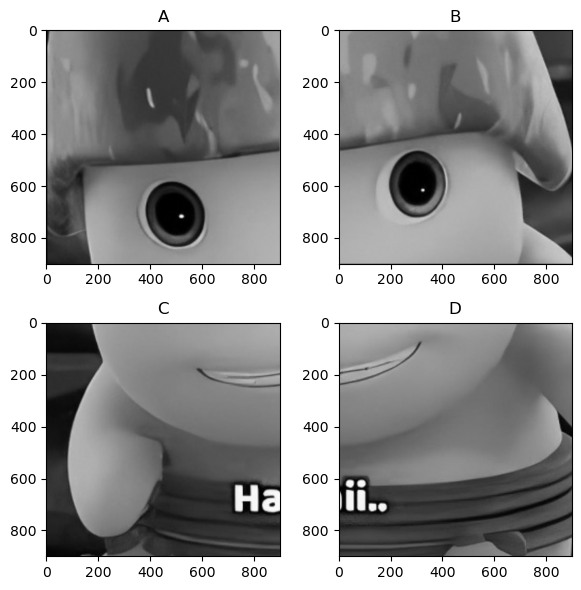

In [26]:
def dilatasi(image, p1=0, p2=0, p3=0, p4=0):

    image = image.astype(np.float32)

    h, w = image.shape

    dilated = np.zeros((h * 2, w * 2), dtype=np.float32)

    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y, x] = image[y // 2, x // 2]

    sy = max(0, p1)
    ey = min(h * 2, h * 2 - p2)

    sx = max(0, p3)
    ex = min(w * 2, w * 2 - p4)

    hasil = dilated[sy:ey, sx:ex]

    return hasil

tebal_bingkai = 200
p_atas = tebal_bingkai
p_bawah = tebal_bingkai
p_kiri = tebal_bingkai
p_kanan = tebal_bingkai

dilatasi_1 = dilatasi(geser1, p1=p_atas, p3=p_kiri)
dilatasi_2 = dilatasi(geser2, p1=p_atas, p4=p_kanan)
dilatasi_3 = dilatasi(geser3, p2=p_bawah, p3=p_kiri)
dilatasi_4 = dilatasi(geser4, p2=p_bawah, p4=p_kanan)

plt.figure(figsize=(6, 6))
plt.subplot(2, 2, 1)
show(dilatasi_1, "A")

plt.subplot(2, 2, 2)
show(dilatasi_2, "B")

plt.subplot(2, 2, 3)
show(dilatasi_3, "C")

plt.subplot(2, 2, 4)
show(dilatasi_4, "D")

plt.tight_layout()
plt.show()

Kode ini mendefinisikan fungsi dilatasi untuk memperbesar dimensi gambar dua kali lipat sekaligus memotong (crop) bagian tepi tertentu, lalu menerapkannya pada keempat gambar sebelumnya dengan sisi pemotongan yang berbeda-beda sejauh 200 piksel, dan menampilkannya kembali ke layar dalam susunan grid 2x2.

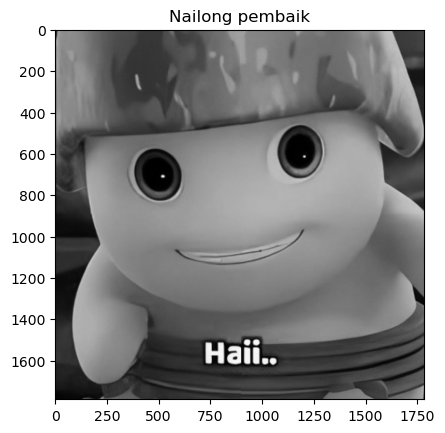

In [ ]:
def merge_atas(A, B): 
    c1, c2 = np.array(A), np.array(B) 
    tinggi = min(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[:, 0:c1.shape[1]] = c1[:tinggi, :] 
    hasil[:, c1.shape[1]:] = c2[:tinggi, :] 
    return hasil

def merge_bawah(C, D): 
    c1, c2 = np.array(C), np.array(D)
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = min(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], :] = c1[:, :lebar]
    hasil[c1.shape[0]:, :] = c2[:, :lebar]
    return hasil

def merge_semua(img1, img2, img3, img4):
    baris_atas = merge_atas(img1[5:, :-8], img2[:-2, 10:])
    baris_bawah = merge_atas(img3[5:, :-1], img4[:-1, 13:])
    hasil_akhir = merge_bawah(baris_atas[:-1, :], baris_bawah[2:, :])
    return hasil_akhir

gambar_utuh = merge_semua(
    dilatasi_1,
    dilatasi_2,
    dilatasi_3,
    dilatasi_4
)

gambar_utuh = gambar_utuh - gambar_utuh.min()

gambar_utuh = (
    gambar_utuh / gambar_utuh.max()
) * 255

gambar_utuh = gambar_utuh.astype(np.uint8)

show(gambar_utuh, "Nailong pembaik")
plt.show()

Kode ini berfungsi untuk menggabungkan keempat potongan gambar sebelumnya menjadi satu gambar utuh melalui proses penyambungan horizontal dan vertikal beserta sedikit pemotongan tepi (crop) untuk menyelaraskan posisinya, yang kemudian dilanjutkan dengan tahap normalisasi intensitas piksel ke rentang standar 0-255 agar gambar dapat ditampilkan dengan kontras yang optimal.

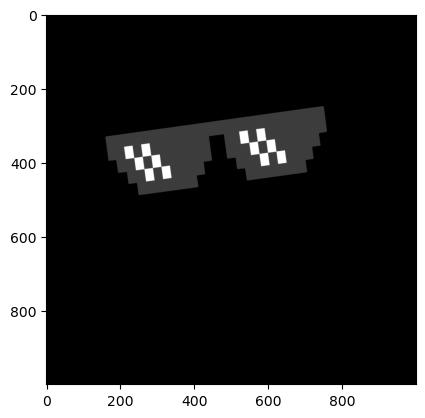

In [28]:
img5 = Image.open("assets/Kacamata.png").convert('L')
plt.imshow(img5, cmap='gray')
plt.show()

Kode ini berfungsi untuk membaca file gambar "Kacamata.png" menggunakan pustaka Pillow, langsung mengonversinya ke dalam format hitam putih (grayscale), dan kemudian menampilkannya ke layar menggunakan Matplotlib.

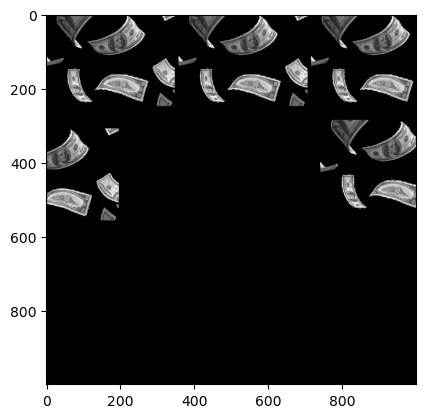

In [29]:
img6 = Image.open("assets/money.png").convert('L')
plt.imshow(img6, cmap='gray')
plt.show()

Kode ini berfungsi untuk membaca file gambar "money.png" menggunakan pustaka Pillow, langsung mengonversinya ke dalam format hitam putih (grayscale), dan kemudian menampilkannya ke layar menggunakan Matplotlib.

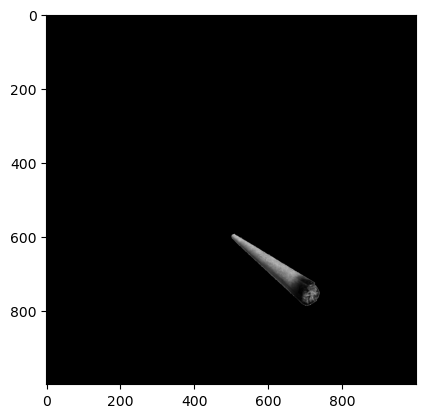

In [30]:
img7 = Image.open("assets/udud.png").convert('L')
plt.imshow(img7, cmap='gray')
plt.show()

Kode ini berfungsi untuk membaca file gambar "udud.png" menggunakan pustaka Pillow, langsung mengonversinya ke dalam format hitam putih (grayscale), dan kemudian menampilkannya ke layar menggunakan Matplotlib.

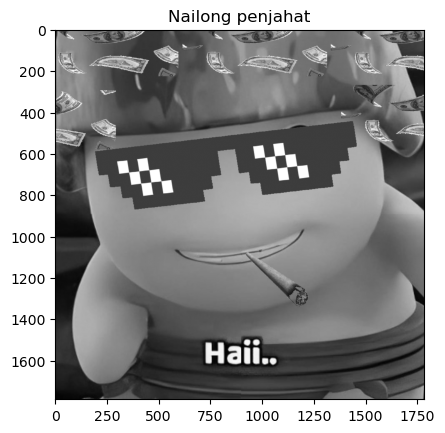

In [31]:
def resize_manual(image, target_h, target_w):

    h, w = image.shape

    hasil = np.zeros((target_h, target_w), dtype=image.dtype)

    for y in range(target_h):
        for x in range(target_w):

            src_y = int(y * h / target_h)
            src_x = int(x * w / target_w)

            hasil[y][x] = image[src_y][src_x]
    return hasil

def overlay_manual(base, overlay_img,
                    x_pos, y_pos,
                    target_w, target_h):

    img_resized = resize_manual(
        overlay_img,
        target_h,
        target_w
    )

    result = base.copy()

    h_base, w_base = result.shape

    for y in range(target_h):
        for x in range(target_w):

            ny = y + y_pos
            nx = x + x_pos

            if 0 <= ny < h_base and 0 <= nx < w_base:

                if img_resized[y][x] > 20:

                    result[ny][nx] = img_resized[y][x]
    return result

nailong_sultan = gambar_utuh.copy()

if nailong_sultan.max() <= 1:
    nailong_sultan = nailong_sultan * 255

nailong_sultan = nailong_sultan.astype(np.uint8)

img5 = np.array(img5)

if len(img5.shape) == 3:

    if img5.shape[-1] == 4:
        img5 = img5[:, :, :3]

    img5 = np.mean(img5, axis=2)

if img5.max() <= 1:
    img5 = img5 * 255

img5 = img5.astype(np.uint8)

img6 = np.array(img6)

if len(img6.shape) == 3:

    if img6.shape[-1] == 4:
        img6 = img6[:, :, :3]

    img6 = np.mean(img6, axis=2)

if img6.max() <= 1:
    img6 = img6 * 255

img6 = img6.astype(np.uint8)

img7 = np.array(img7)

if len(img7.shape) == 3:

    if img7.shape[-1] == 4:
        img7 = img7[:, :, :3]

    img7 = np.mean(img7, axis=2)

if img7.max() <= 1:
    img7 = img7 * 255

img7 = img7.astype(np.uint8)

Kacamata_crop = img5[80:520, 50:950]

Money_crop = img6[50:750, 50:950]

Udud_crop = img7[250:950, 200:950]

nailong_sultan = overlay_manual(

    base        = nailong_sultan,

    overlay_img = Kacamata_crop,

    x_pos       = -40,
    y_pos       = 145,

    target_w    = 1900,
    target_h    = 780
)

nailong_sultan = overlay_manual(

    base        = nailong_sultan,

    overlay_img = Money_crop,

    x_pos       = 0,
    y_pos       = 0,

    target_w    = 1800,
    target_h    = 800
)

nailong_sultan = overlay_manual(

    base        = nailong_sultan,

    overlay_img = Udud_crop,

    x_pos       = 540,
    y_pos       = 610,

    target_w    = 950,
    target_h    = 950
)

plt.imshow(nailong_sultan, cmap='gray')

plt.title("Nailong penjahat")
plt.show()

Kode ini mendefinisikan fungsi manual untuk mengubah ukuran dan menumpuk gambar (overlay), lalu menggunakannya untuk menempelkan beberapa aksesoris yang sudah dipotong dan dikonversi ke format grayscale seperti kacamata, uang, dan rokok ke atas gambar utama, untuk kemudian menampilkan hasil akhir gambar gabungannya ke layar.

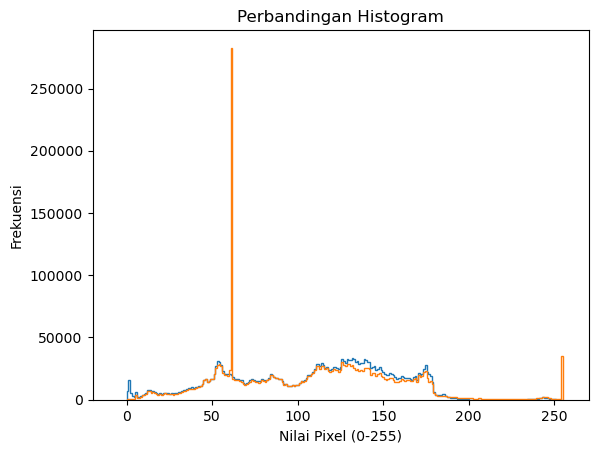

In [32]:
plt.hist(
    gambar_utuh.flatten(),
    bins=256,
    range=[0,255],
    histtype='step',
    linewidth=1,
    label='Gambar Utuh'
)

plt.hist(
    nailong_sultan.flatten(),
    bins=256,
    range=[0,255],
    histtype='step',
    linewidth=1,
    label='Nailong Sultan'
)

plt.title("Perbandingan Histogram")
plt.xlabel("Nilai Pixel (0-255)")
plt.ylabel("Frekuensi")

plt.xlim([-20, 270])

plt.show()

Kode ini berfungsi untuk menghitung dan menampilkan grafik histogram perbandingan dari kedua gambar ("Gambar Utuh" dan "Nailong Sultan") dalam bentuk garis tepi (outline) yang tipis, beserta pengaturan judul, label sumbu, dan penyesuaian batas sumbu X (`plt.xlim`) untuk memberikan sedikit ruang kosong visual di sisi kiri dan kanan grafik.